# Stage 5 - Model Training

## Purpose
Train three supervised learning models on the prepared feature matrices
from stage 4 and identify the best performer using cross-validation.

## Models Trained
| Model | Type | Why |
|-------|------|-----|
| Logistic Regression | Linear | Interpretable baseline- sets our minimum bar |
| Random Forest | Ensemble | Handles non-linearity - robust to outliers |
| XGBoost | Gradient Boosting | State-of-the-art tabular performance |

## Key Principle - No Test Set Touch
The test set (X_test, y_test) is NOT used in this stage.
Cross-validation runs entirely on training data.
Test set is reserved exclusively for stage 6 (Evaluation).

In [1]:
# Import all libraries

import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics         import classification_report, roc_auc_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# Load all four datasets from stage 4

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'
FIGURES_PATH   = '../reports/figures/'
os.makedirs(MODELS_PATH, exist_ok=True)

X_train = pd.read_csv(f'{PROCESSED_PATH}X_train.csv')
X_test  = pd.read_csv(f'{PROCESSED_PATH}X_test.csv')
y_train = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()
y_test  = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()

print("Datasets loaded successfully")
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train : {y_train.shape} - churn rate: {y_train.mean()*100:.2f}%") 
print(f"y_test : {y_test.shape} - churn rate: {y_test.mean()*100:.2f}%")



Datasets loaded successfully
X_train : (5625, 30)
X_test : (1407, 30)
y_train : (5625,) - churn rate: 26.58%
y_test : (1407,) - churn rate: 26.58%


In [3]:
# Setup cross-validation strategy

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation strategy:")
print(f"  Method    : StratifiedKfold")
print(f"  Folds     : 5")
print(f" Scoring    : ROU-AUC")
print(f" Train rows per fold : ~{int(X_train.shape[0] * 0.8):,}")
print(f" Train val  per fold : ~{int(X_train.shape[0] * 0.2):,}")

Cross-validation strategy:
  Method    : StratifiedKfold
  Folds     : 5
 Scoring    : ROU-AUC
 Train rows per fold : ~4,500
 Train val  per fold : ~1,125


In [4]:
# Train and cross-validate Logistic Regression

lr_model = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = 42 
)

lr_cv_scores = cross_val_score(
    lr_model, X_train, y_train,
    cv       = cv,
    scoring = 'roc_auc'
)

print("LogisticRegression - 5-fold cross-validation results:")
print(f"   Fold scores  : {[f'{s:.4f}' for s in lr_cv_scores]}")
print(f"   Mean AUC     : {lr_cv_scores.mean():.4f}")
print(f"   std AUC      : {lr_cv_scores.std():.4f}  (lower = moe stable)")
print()
print("Fitting final model on full training set...")
lr_model.fit(X_train, y_train)
print("Done.")

LogisticRegression - 5-fold cross-validation results:
   Fold scores  : ['0.8467', '0.8430', '0.8373', '0.8495', '0.8530']
   Mean AUC     : 0.8459
   std AUC      : 0.0054  (lower = moe stable)

Fitting final model on full training set...
Done.


In [5]:
# Train and cross-validate Random Forest

rf_model = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_leaf  = 4,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1  
)

rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv       = cv,
    scoring  = 'roc_auc'
)

print("Random Forest - 5fold cross-validation results:")
print(f"  Fold scores   : {[f'{s:.4f}' for s in rf_cv_scores]}")
print(f"  Mean AUC      : {rf_cv_scores.mean():.4f}")
print(f"  std AUC       : {rf_cv_scores.std():.4f}")
print()
print("Fitting final model on full training set...")
rf_model.fit(X_train, y_train)
print("Done.")

Random Forest - 5fold cross-validation results:
  Fold scores   : ['0.8423', '0.8423', '0.8469', '0.8522', '0.8557']
  Mean AUC      : 0.8479
  std AUC       : 0.0053

Fitting final model on full training set...
Done.


In [6]:
# Calculate class imbalance ratio for XGBoost

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

print(f"Training set class counts:")
print(f"  Retained (0) : {neg_count:,}")
print(f"  Churned  (1) : {pos_count:,}")
print(f" scale_pos_weight = {neg_count}/{pos_count} = {scale_pos:.3f}")

Training set class counts:
  Retained (0) : 4,130
  Churned  (1) : 1,495
 scale_pos_weight = 4130/1495 = 2.763


In [7]:
 # Train and cross-validate for XGBoost

xgb_model = XGBClassifier(
    n_estimators     = 300,
    mex_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    eval_metric      = 'auc',
    random_state     = 42,
    verbosity        = 0
)

xgb_cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv        = cv,
    scoring   = 'roc_auc'
)

print("XGBoost - 5-fold cross-validation results:")
print(f"  Fold scores   : {[f'{s:.4f}' for s in xgb_cv_scores]}")
print(f"  Mean AUC      : {xgb_cv_scores.mean():.4f}")
print(f"  std AUC       : {xgb_cv_scores.std():.4f}")
print()
print("Fittin final model on full training set...")
xgb_model.fit(X_train, y_train)
print("Done.")

XGBoost - 5-fold cross-validation results:
  Fold scores   : ['0.8355', '0.8271', '0.8376', '0.8436', '0.8468']
  Mean AUC      : 0.8381
  std AUC       : 0.0068

Fittin final model on full training set...
Done.


In [8]:
# Side-by-Side comparision table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'CV Mean AUC' :[
        lr_cv_scores.mean()   ,
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    'CV Std AUC': [
        lr_cv_scores.min(),
        rf_cv_scores.min(),
        xgb_cv_scores.min()
    ],
    'Min Fold': [
        lr_cv_scores.min(),
        rf_cv_scores.min(),
        xgb_cv_scores.min()
    ],
    'Max Fold': [
        lr_cv_scores.max(),
        rf_cv_scores.max(),
        xgb_cv_scores.max()
    ]
})

results = results.sort_values('CV Mean AUC', ascending=False).reset_index(drop=True)
results[['CV Mean AUC', 'CV Std AUC', 'Min Fold', 'Max Fold']] = \
    results[['CV Mean AUC', 'CV Std AUC', 'Min Fold', 'Max Fold']].round(4)

print('=' * 65)
print("  MODEL COMPARISION - 5-FOLD CROSS-VALIDATION ON TRAINING SET")
print('=' * 65)
print(results.to_string(index=False))
print("=" * 65)
print()
best_model_name = results.iloc[0]['Model']
best_auc        = results.iloc[0]['CV Mean AUC']
print(f"Best model: {best_model_name}  (CV AUC = {best_auc:.4f})")

  MODEL COMPARISION - 5-FOLD CROSS-VALIDATION ON TRAINING SET
              Model  CV Mean AUC  CV Std AUC  Min Fold  Max Fold
      Random Forest       0.8479      0.8423    0.8423    0.8557
Logistic Regression       0.8459      0.8373    0.8373    0.8530
            XGBoost       0.8381      0.8271    0.8271    0.8468

Best model: Random Forest  (CV AUC = 0.8479)


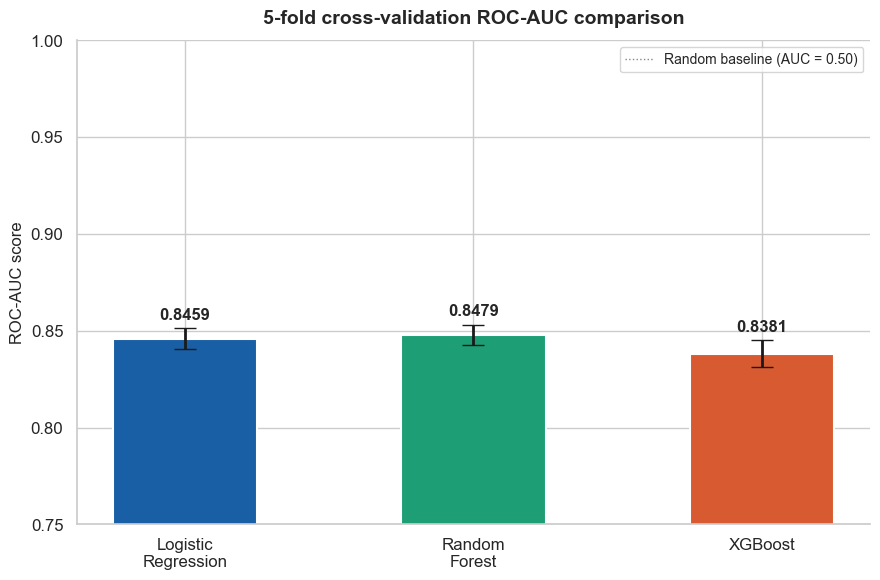

Saved: 09_model_cv_comparison.png


In [9]:
# Visualise the cross-validation score distributions

model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
means       = [lr_cv_scores.mean(), rf_cv_scores.mean(), xgb_cv_scores.mean()]
stds        = [lr_cv_scores.std(),  rf_cv_scores.std(), xgb_cv_scores.std()]
colors      = ['#185FA5','#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(model_names, means, yerr=stds,
              color=colors, width=0.5,
              edgecolor='white', linewidth=1.5,
              capsize=8, error_kw={'linewidth': 2, 'color': '#2C2C2A'})

# Label each bar with its mean AUC
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{mean:.4f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_title('5-fold cross-validation ROC-AUC comparison',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('ROC-AUC score', fontsize=12)
ax.set_ylim(0.75, 1.0)
ax.axhline(0.5, color='#888780', linestyle=':', linewidth=1,
           label='Random baseline (AUC = 0.50)')
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}09_model_cv_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 09_model_cv_comparison.png")



In [10]:
# Quick training predictions for sanity check only

print("Training set AUC (sanity check - NOT final evaluation):")
print("High training AUC is expected. Real evaluation is in stage 6.")
print()

models = {
    'Logistic Regression' : lr_model,
    'Random Forest'       : rf_model,
    'XGBoost'             : xgb_model
}

for name, model in models.items():
    train_proba = model.predict_proba(X_train)[:,1]
    train_auc   = roc_auc_score(y_train, train_proba)
    print(f"  {name:<25} Train AUC: {train_auc:.4f}")

print()
print("Note: gap between Train AUC and CV AUC indicates overfittig level.")
print("A gap under 0.05 is acceptable. Large gaps require regularisation.")

Training set AUC (sanity check - NOT final evaluation):
High training AUC is expected. Real evaluation is in stage 6.

  Logistic Regression       Train AUC: 0.8505
  Random Forest             Train AUC: 0.9193
  XGBoost                   Train AUC: 0.9664

Note: gap between Train AUC and CV AUC indicates overfittig level.
A gap under 0.05 is acceptable. Large gaps require regularisation.


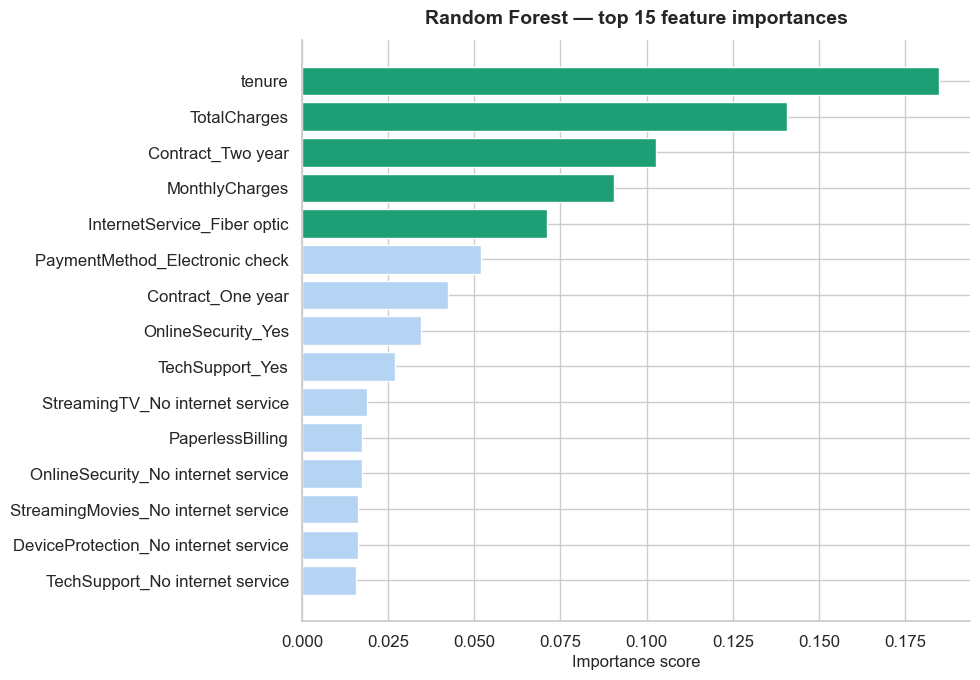

Saved: 10_rf_feature_importance.png


In [11]:
# Feature importance from Random Forest

feature_names = X_train.columns.tolist()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index = feature_names
    ).sort_values(ascending=False).head(15)    


fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1D9E75' if i < 5 else '#B5D4F4'
          for i in range(len(rf_importance))]

ax.barh(rf_importance.index[::-1],
        rf_importance.values[::-1],
        color=colors[::-1], edgecolor='white', linewidth=1)

ax.set_title('Random Forest — top 15 feature importances',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance score', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}10_rf_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: 10_rf_feature_importance.png")


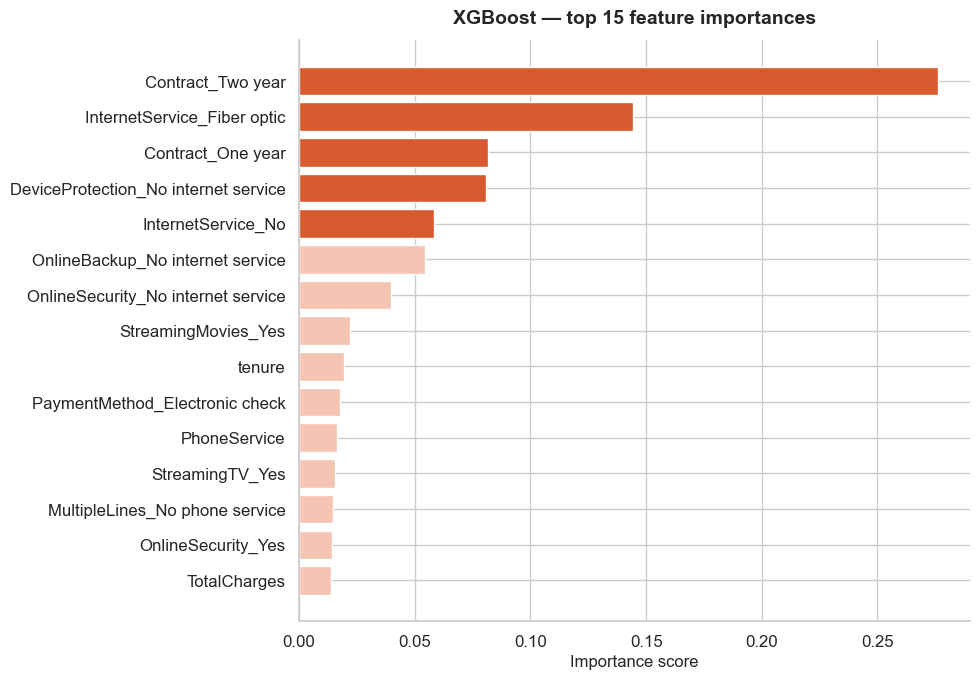

Saved: 11_xgb_feature_importance.png


In [12]:
# Feature importance from XGBoost

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index = feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#D85A30' if i < 5 else '#F5C4B3'
          for i in range(len(xgb_importance))]

ax.barh(xgb_importance.index[::-1],
        xgb_importance.values[::-1],
        color=colors[::-1], edgecolor='white', linewidth=1)

ax.set_title('XGBoost — top 15 feature importances',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance score', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}11_xgb_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: 11_xgb_feature_importance.png")

In [13]:
# Save all three trained models to disk

model_files = {
    'Logistic_regression.pkl' : lr_model,
    'random_forest.pkl'       : rf_model,
    'xgboost.pkl'             : xgb_model
}

for filename, model in model_files.items():
    filepath = os.path.join(MODELS_PATH, filename)
    joblib.dump(model, filepath)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"Saved: {filename:<30} ({size_kb:.0f} KB)")

    print()
    print(f"All models saved to: {MODELS_PATH}")

Saved: Logistic_regression.pkl        (2 KB)

All models saved to: ../models/
Saved: random_forest.pkl              (11616 KB)

All models saved to: ../models/
Saved: xgboost.pkl                    (990 KB)

All models saved to: ../models/


In [14]:
# Stage 5 Complete summary

print("=" * 65)
print("  STAGE 5 — MODEL TRAINING COMPLETE")
print("=" * 65)
print(f"""
  MODELS TRAINED
    1. Logistic Regression  CV AUC = {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}
    2. Random Forest        CV AUC = {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}
    3. XGBoost              CV AUC = {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}

  BEST MODEL (by CV AUC)
    {best_model_name}  —  AUC = {best_auc:.4f}

  FILES SAVED
    models/logistic_regression.pkl
    models/random_forest.pkl
    models/xgboost.pkl

  FIGURES SAVED
    reports/figures/09_model_cv_comparison.png
    reports/figures/10_rf_feature_importance.png
    reports/figures/11_xgb_feature_importance.png

  IMPORTANT
    Test set has NOT been used in this stage.
    Full evaluation on unseen data happens in Stage 6.
""")
print("=" * 65)
print("  Ready for Stage 6 — Model Evaluation")
print("=" * 65)

  STAGE 5 — MODEL TRAINING COMPLETE

  MODELS TRAINED
    1. Logistic Regression  CV AUC = 0.8459 ± 0.0054
    2. Random Forest        CV AUC = 0.8479 ± 0.0053
    3. XGBoost              CV AUC = 0.8381 ± 0.0068

  BEST MODEL (by CV AUC)
    Random Forest  —  AUC = 0.8479

  FILES SAVED
    models/logistic_regression.pkl
    models/random_forest.pkl
    models/xgboost.pkl

  FIGURES SAVED
    reports/figures/09_model_cv_comparison.png
    reports/figures/10_rf_feature_importance.png
    reports/figures/11_xgb_feature_importance.png

  IMPORTANT
    Test set has NOT been used in this stage.
    Full evaluation on unseen data happens in Stage 6.

  Ready for Stage 6 — Model Evaluation
